$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\E}{\mathbb{E}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\yv}{\mathbf{y}}
\providecommand{\thetav}{\bm{\theta}}
\providecommand{\thetab}{\bm{\theta}}
$$

Consider ordinary linear least squares (without intercept):

$$\min_{\bm{\theta}} \E_{\xv, y}\!\left[(\bm{\theta}^\top \xv - y)^2\right]$$

with $\xv \sim \mathcal{N}(\mathbf{0}, \bm{\Sigma}_\xv)$ and $y \mid \xv \sim \mathcal{N}({\bm{\theta}^*}^\top \xv, \sigma^2)$. Throughout the coding parts we use the univariate setting $\bm{\Sigma}_\xv = 1/4$, $\sigma = 1/10$, $\bm{\theta}^* = 1/2$. Each coding cell draws fresh samples from this generative model (fresh mini-batches in (c); streaming single samples in (e)).

::: callout-note
**R vs. Python parity.** R's `set.seed(123)` and Python's `np.random.seed(123)` use *different* RNGs. The data above (and consequently the SGD trajectories below) differ between languages. Both implementations are correct; only the underlying data differs. Compare *algorithmic behavior* (cloud shape, convergence pattern) rather than expecting numerically identical $\bm{\theta}$ values.
:::

## (a) Unbiasedness of the SGD gradient

Show that

$$\E_{\xv, y}\!\left[\nabla_{\bm{\theta}}\!\left[(\bm{\theta}^\top \xv - y)^2\right]\right] = \nabla_{\bm{\theta}} \E_{\xv, y}\!\left[(\bm{\theta}^\top \xv - y)^2\right].$$

**Solution.**

We compute both expressions and compare the results.

$$\begin{aligned}
\E_{\xv, y}\!\left[\nabla_{\thetab}\!\left[(\thetab^\top \xv - y)^2\right]\right]
  &= \E_{\xv, y}\!\left[2 \xv \xv^\top \thetab - 2 \xv y\right] \\
  &= \E_\xv \E_{y \mid \xv}\!\left[2 \xv \xv^\top \thetab - 2 \xv y\right] \\
  &= \E_\xv\!\left[2 \xv \xv^\top \thetab - 2 \xv \xv^\top \thetab^*\right] \\
  &= 2 \bm{\Sigma}_\xv (\thetab - \thetab^*).
\end{aligned}$$

$$\begin{aligned}
\nabla_{\thetab} \E_{\xv, y}\!\left[(\thetab^\top \xv - y)^2\right]
  &= \nabla_{\thetab} \E_{\xv, y}\!\left[\thetab^\top \xv \xv^\top \thetab - 2 \thetab^\top \xv y + y^2\right] \\
  &= \nabla_{\thetab} \E_\xv\!\left[\thetab^\top \xv \xv^\top \thetab\right]
     - \nabla_{\thetab} \E_{\xv, y}\!\left[2 \thetab^\top \xv y\right]
     + \nabla_{\thetab} \E_y\!\left[y^2\right] \\
  &= 2 \bm{\Sigma}_\xv \thetab - 2 \nabla_{\thetab} \E_\xv \E_{y \mid \xv}\!\left[\thetab^\top \xv y\right] \\
  &= 2 \bm{\Sigma}_\xv \thetab - 2 \nabla_{\thetab} \E_\xv \E_{y \mid \xv}\!\left[\thetab^\top \xv \xv^\top \thetab^*\right] \\
  &= 2 \bm{\Sigma}_\xv \thetab - 2 \nabla_{\thetab}\!\left(\thetab^\top \bm{\Sigma}_\xv \thetab^*\right) \\
  &= 2 \bm{\Sigma}_\xv \thetab - 2 \bm{\Sigma}_\xv \thetab^* \\
  &= 2 \bm{\Sigma}_\xv (\thetab - \thetab^*).
\end{aligned}$$

## (b) Implication for SGD

Interpret (a) in terms of stochastic gradient descent.

**Solution.**

We can estimate $\E_{\xv, y}[\nabla_{\thetab}[(\thetab^\top \xv - y)^2]]$ without bias via SGD, since we have access to realizations of the gradients $\nabla_{\thetab}[(\thetab^\top \xv - y)^2]$. From (a), it follows that this estimate is also an unbiased estimate of the gradient of our objective function $\nabla_{\thetab}\E_{\xv, y}[(\thetab^\top \xv - y)^2]$. Hence, SGD can be successfully applied in this situation.

## (c) Gradient variance simulation

In the univariate setting $\bm{\Sigma}_\xv = 1/4$, $\sigma = 1/10$, $\bm{\theta}^* = 1/2$, with data of size $10{,}000$:

Plot the **confusion** (variance of the SGD gradient around the true full-batch gradient) for $\theta \in \{0, 0.05, 0.10, \ldots, 1.00\}$. For each $\theta$ draw $200$ independent batches and plot the per-batch confusion. Repeat for batch sizes $m = 100$ and $m = 1{,}000$.

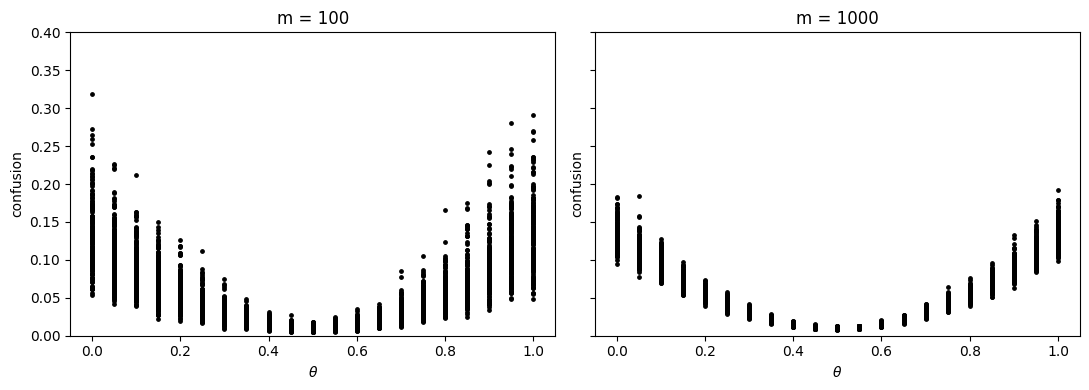

In [1]:
#| label: solution_c_code
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)
sigma_x = 0.5   # Sigma_x = 1/4, so sd = 1/2
sigma_y = 0.1
theta_star = 0.5

# data of size n (drawn once; each confusion below re-samples a fresh batch)
n = 10000
x = np.sort(np.random.normal(0, sigma_x, n))
y = theta_star * x + np.random.normal(0, sigma_y, n)


def compute_conf(theta, m):
    # confusion: mean squared deviation of the per-sample gradients from the
    # population gradient 2 * sigma_x^2 * (theta - theta_star)
    x = np.random.normal(0, sigma_x, m)
    y = theta_star * x + np.random.normal(0, sigma_y, m)
    per_sample = 2 * (x * x * theta - y * x)
    pop_grad = 2 * sigma_x ** 2 * (theta - theta_star)
    return float(np.mean((per_sample - pop_grad) ** 2))


thetas = np.linspace(0, 1, 21)
reps = 200


def run_grid(m):
    out = np.empty(reps * len(thetas))
    k = 0
    for _ in range(reps):
        for th in thetas:
            out[k] = compute_conf(th, m); k += 1
    return out


vals_100 = run_grid(100)
vals_1000 = run_grid(1000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, vals, m_lbl in zip(axes, (vals_100, vals_1000), (100, 1000)):
    ax.scatter(np.tile(thetas, reps), vals, s=6, color="black")
    ax.set_ylim(0, 0.4)
    ax.set_xlabel(r"$\theta$"); ax.set_ylabel("confusion")
    ax.set_title(f"m = {m_lbl}")
plt.tight_layout()
plt.show()

For each $\theta$ and batch size $m$ we draw a fresh batch and measure the *confusion*: the mean squared deviation of the per-sample gradients $2(x_i^2 \theta - y_i x_i)$ from the population gradient $g(\theta) = 2\sigma_x^2(\theta - \theta^*)$. This estimates the sample-to-sample variance of the gradient at $\theta$, which the larger batch $m = 1000$ pins down more tightly than $m = 100$.

## (d) Reading the simulation

What do you observe in (c)?

**Solution.**

Qualitatively, we observe for both settings that the mean and the variance of the confusion rise symmetrically around $\thetab^*$. As expected, the mean and the variance of the confusion are smaller for the larger batch size $m = 1000$ than for $m = 100$.

## (e) SGD vs population GD

On the same setup, run SGD with **batch size 1**, step size $\alpha = 0.3$, starting at $\bm{\theta} = 0$, for 20 iterations. Repeat the SGD run 200 times and overlay all trajectories. Compare with **population GD** (same step size, same start) using the analytical gradient $g(\theta) = 2\sigma_x^2(\theta - \theta^*)$.

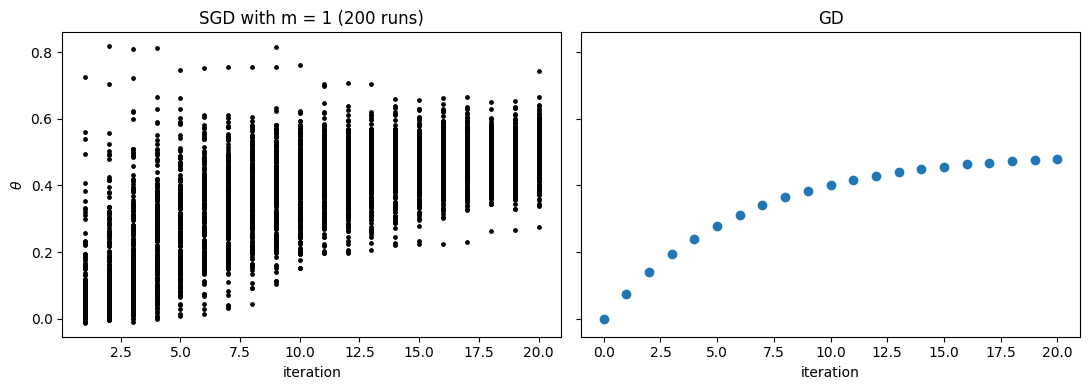

After 20 iters:  SGD mean = +0.4862, sd = 0.0688;  GD theta = +0.4806  (theta* = 0.5000)


In [2]:
#| label: solution_e_code
np.random.seed(123)
alpha = 0.3
n_iters = 20
n_runs = 200
m = 1

# SGD with batch size 1
sgd_traces = np.empty((n_runs, n_iters))
for j in range(n_runs):
    theta = 0.0
    for i in range(n_iters):
        x = np.random.normal(0, sigma_x, m)
        y = theta_star * x + np.random.normal(0, sigma_y, m)
        theta = theta - alpha * np.mean(2 * (x * x * theta - y * x))
        sgd_traces[j, i] = theta

# Population GD using the analytical gradient
# 2 * sigma_x^2 * (theta - theta_star)
theta = 0.0
gd_trace = [theta]
for i in range(n_iters):
    theta = theta - alpha * 2 * sigma_x ** 2 * (theta - theta_star)
    gd_trace.append(theta)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sgd_it = np.arange(1, n_iters + 1)
for j in range(n_runs):
    axes[0].scatter(sgd_it, sgd_traces[j], s=6, color="black")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel(r"$\theta$")
axes[0].set_title("SGD with m = 1 (200 runs)")
axes[1].scatter(np.arange(len(gd_trace)), gd_trace)
axes[1].set_xlabel("iteration"); axes[1].set_title("GD")
plt.tight_layout()
plt.show()

print(f"After 20 iters:  SGD mean = {sgd_traces[:, -1].mean():+.4f}, "
      f"sd = {sgd_traces[:, -1].std():.4f};  "
      f"GD theta = {gd_trace[-1]:+.4f}  (theta* = {theta_star:.4f})")